In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             accuracy_score,
                             f1_score)
import joblib

os.makedirs('../outputs/figures', exist_ok=True)

X_train = pd.read_csv('../outputs/X_train.csv')
X_test  = pd.read_csv('../outputs/X_test.csv')
y_train = pd.read_csv('../outputs/y_train.csv').squeeze()
y_test  = pd.read_csv('../outputs/y_test.csv').squeeze()

print("Loaded successfully!")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("Pass rate in test:", round(y_test.mean()*100, 1), "%")

Loaded successfully!
X_train: (316, 39)
X_test : (79, 39)
Pass rate in test: 67.1 %


In [2]:
# Define all 3 models
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=5000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=4, random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=4,
        class_weight='balanced',    # handles imbalance without SMOTE
        random_state=42)
}

# Cross validation on training data (more reliable than single split)
print("===== 5-Fold Cross Validation on Training Data =====\n")
cv_results = {}
for name, model in models.items():
    cv_scores = cross_val_score(
        model, X_train, y_train,
        cv=5, scoring='accuracy')
    cv_results[name] = cv_scores
    print(f"{name}")
    print(f"  CV Accuracy : {cv_scores.mean()*100:.1f}% "
          f"(+/- {cv_scores.std()*100:.1f}%)")
    print()

===== 5-Fold Cross Validation on Training Data =====

Logistic Regression
  CV Accuracy : 69.0% (+/- 2.8%)

Decision Tree
  CV Accuracy : 69.3% (+/- 3.2%)

Random Forest
  CV Accuracy : 71.8% (+/- 4.1%)



In [3]:
print("===== Test Set Results =====\n")
test_results = {}

for name, model in models.items():
    # Train on full training set
    model.fit(X_train, y_train)
    pred     = model.predict(X_test)
    accuracy = accuracy_score(y_test, pred)
    f1       = f1_score(y_test, pred)

    test_results[name] = {
        'model'    : model,
        'pred'     : pred,
        'accuracy' : accuracy,
        'f1'       : f1
    }

    print(f"--- {name} ---")
    print(f"Accuracy : {accuracy*100:.1f}%")
    print(f"F1 Score : {f1:.2f}")
    print(classification_report(y_test, pred,
          target_names=['Fail', 'Pass']))

===== Test Set Results =====

--- Logistic Regression ---
Accuracy : 65.8%
F1 Score : 0.76
              precision    recall  f1-score   support

        Fail       0.47      0.35      0.40        26
        Pass       0.72      0.81      0.76        53

    accuracy                           0.66        79
   macro avg       0.60      0.58      0.58        79
weighted avg       0.64      0.66      0.64        79

--- Decision Tree ---
Accuracy : 64.6%
F1 Score : 0.75
              precision    recall  f1-score   support

        Fail       0.45      0.38      0.42        26
        Pass       0.72      0.77      0.75        53

    accuracy                           0.65        79
   macro avg       0.59      0.58      0.58        79
weighted avg       0.63      0.65      0.64        79

--- Random Forest ---
Accuracy : 69.6%
F1 Score : 0.79
              precision    recall  f1-score   support

        Fail       0.56      0.38      0.45        26
        Pass       0.74      0.85   

In [4]:
print("===== Model Comparison =====\n")

comparison = pd.DataFrame({
    'Model': list(test_results.keys()),
    'CV Accuracy': [f"{cv_results[m].mean()*100:.1f}%" 
                    for m in test_results],
    'Test Accuracy': [f"{test_results[m]['accuracy']*100:.1f}%" 
                      for m in test_results],
    'F1 Score': [f"{test_results[m]['f1']:.2f}" 
                 for m in test_results]
})
print(comparison.to_string(index=False))

# Pick best by F1
best_name  = max(test_results, 
                 key=lambda m: test_results[m]['f1'])
best_model = test_results[best_name]['model']
best_pred  = test_results[best_name]['pred']

print(f"\nBest model: {best_name}")
print(f"F1 Score  : {test_results[best_name]['f1']:.2f}")

===== Model Comparison =====

              Model CV Accuracy Test Accuracy F1 Score
Logistic Regression       69.0%         65.8%     0.76
      Decision Tree       69.3%         64.6%     0.75
      Random Forest       71.8%         69.6%     0.79

Best model: Random Forest
F1 Score  : 0.79


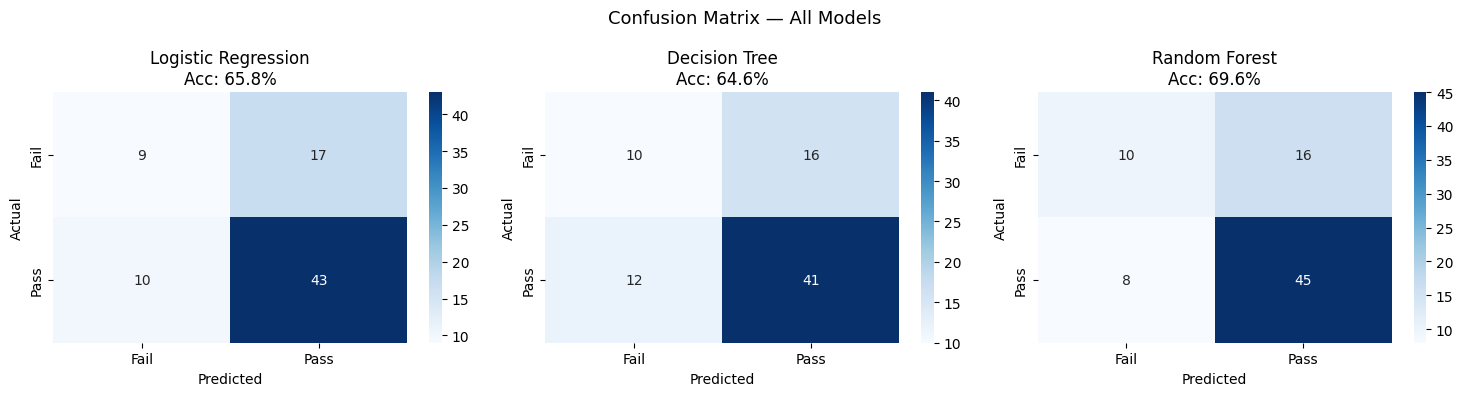

Saved!


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, res) in zip(axes, test_results.items()):
    cm = confusion_matrix(y_test, res['pred'])
    sns.heatmap(cm,
                annot=True, fmt='d',
                cmap='Blues',
                xticklabels=['Fail', 'Pass'],
                yticklabels=['Fail', 'Pass'],
                ax=ax)
    ax.set_title(f"{name}\nAcc: {res['accuracy']*100:.1f}%")
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrix — All Models', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/figures/confusion_matrix.png', dpi=150)
plt.show()
print("Saved!")

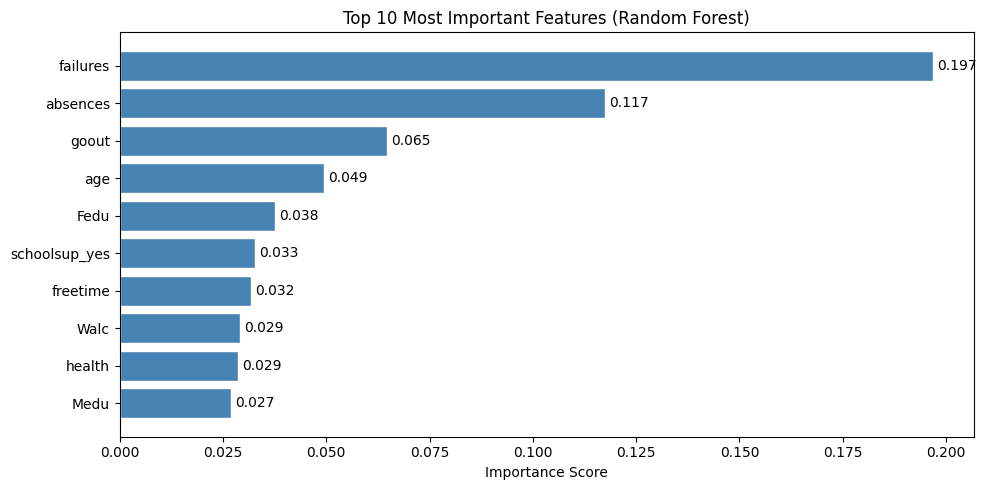

Saved!


In [6]:
# Random Forest feature importance
rf_model = test_results['Random Forest']['model']

importances = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
bars = plt.barh(importances.index[::-1],
                importances.values[::-1],
                color='steelblue', edgecolor='white')

for bar, val in zip(bars, importances.values[::-1]):
    plt.text(bar.get_width() + 0.001,
             bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=10)

plt.title('Top 10 Most Important Features (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../outputs/figures/feature_importance.png', dpi=150)
plt.show()
print("Saved!")

In [7]:
joblib.dump(best_model, '../outputs/best_model.pkl')

# Verify
loaded  = joblib.load('../outputs/best_model.pkl')
v_pred  = loaded.predict(X_test)
v_acc   = accuracy_score(y_test, v_pred)

print(f"Best model saved : {best_name}")
print(f"Verified accuracy: {v_acc*100:.1f}%")

Best model saved : Random Forest
Verified accuracy: 69.6%


In [8]:
best_acc = test_results[best_name]['accuracy']
best_f1  = test_results[best_name]['f1']
best_cv  = cv_results[best_name].mean()

print("========== FINAL RESULTS ==========")
print(f"Dataset        : UCI Student Performance")
print(f"Total students : 395")
print(f"Features used  : {X_train.shape[1]}")
print(f"Best model     : {best_name}")
print(f"CV Accuracy    : {best_cv*100:.1f}%")
print(f"Test Accuracy  : {best_acc*100:.1f}%")
print(f"F1 Score       : {best_f1:.2f}")
print("====================================")

# Honest interpretation
print("\n===== What this means =====")
cm = confusion_matrix(y_test, best_pred)
print(f"Failing students caught   : {cm[0][0]} out of {cm[0].sum()}")
print(f"Passing students caught   : {cm[1][1]} out of {cm[1].sum()}")
print(f"At-risk students missed   : {cm[0][1]} out of {cm[0].sum()}")

========== FINAL RESULTS ==========
Dataset        : UCI Student Performance
Total students : 395
Features used  : 39
Best model     : Random Forest
CV Accuracy    : 71.8%
Test Accuracy  : 69.6%
F1 Score       : 0.79

===== What this means =====
Failing students caught   : 10 out of 26
Passing students caught   : 45 out of 53
At-risk students missed   : 16 out of 26


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

os.makedirs('../outputs/figures', exist_ok=True)

# Load data and best model
X_train = pd.read_csv('../outputs/X_train.csv')
X_test  = pd.read_csv('../outputs/X_test.csv')
y_train = pd.read_csv('../outputs/y_train.csv').squeeze()
y_test  = pd.read_csv('../outputs/y_test.csv').squeeze()
best_model = joblib.load('../outputs/best_model.pkl')

# Load original unscaled data for insight analysis
df = pd.read_csv('../data/student-mat.csv', sep=';')
df['pass'] = (df['G3'] >= 10).astype(int)

print("Everything loaded successfully!")
print("Original data shape :", df.shape)
print("X_train shape       :", X_train.shape)

Everything loaded successfully!
Original data shape : (395, 34)
X_train shape       : (316, 39)


In [10]:
# Get feature importances from Random Forest
importances = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

# Show top 15
print("===== Top 15 Most Important Features =====\n")
for i, (feature, score) in enumerate(importances.head(15).items(), 1):
    bar = '█' * int(score * 200)
    print(f"{i:>2}. {feature:<25} {score:.3f}  {bar}")

===== Top 15 Most Important Features =====

 1. failures                  0.197  ███████████████████████████████████████
 2. absences                  0.117  ███████████████████████
 3. goout                     0.065  ████████████
 4. age                       0.049  █████████
 5. Fedu                      0.038  ███████
 6. schoolsup_yes             0.033  ██████
 7. freetime                  0.032  ██████
 8. Walc                      0.029  █████
 9. health                    0.029  █████
10. Medu                      0.027  █████
11. Dalc                      0.027  █████
12. studytime                 0.025  ████
13. higher_yes                0.024  ████
14. Mjob_health               0.024  ████
15. famrel                    0.023  ████


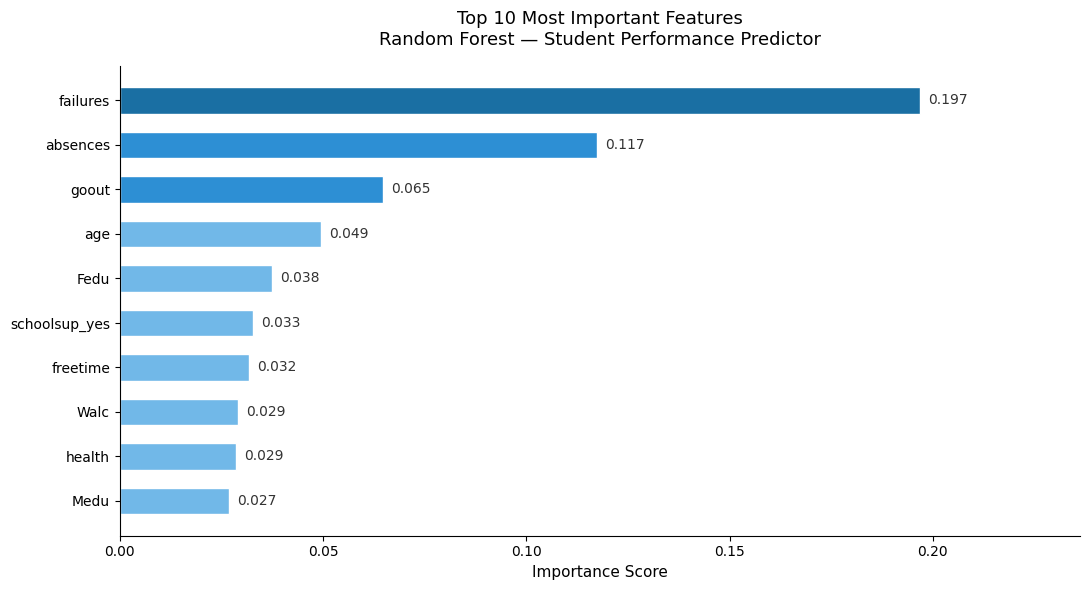

Saved to outputs/figures/feature_importance.png


In [11]:
top10 = importances.head(10)

fig, ax = plt.subplots(figsize=(11, 6))

colors = ['#1a6fa3' if i == 0 else
          '#2d8fd4' if i < 3 else
          '#71b8e8'
          for i in range(len(top10))]

bars = ax.barh(
    top10.index[::-1],
    top10.values[::-1],
    color=colors[::-1],
    edgecolor='white',
    height=0.6
)

# Add value labels on each bar
for bar, val in zip(bars, top10.values[::-1]):
    ax.text(bar.get_width() + 0.002,
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}',
            va='center', fontsize=10,
            color='#333333')

ax.set_title('Top 10 Most Important Features\n'
             'Random Forest — Student Performance Predictor',
             fontsize=13, pad=15)
ax.set_xlabel('Importance Score', fontsize=11)
ax.set_xlim(0, top10.values.max() * 1.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='y', labelsize=10)

plt.tight_layout()
plt.savefig('../outputs/figures/feature_importance.png', dpi=150)
plt.show()
print("Saved to outputs/figures/feature_importance.png")

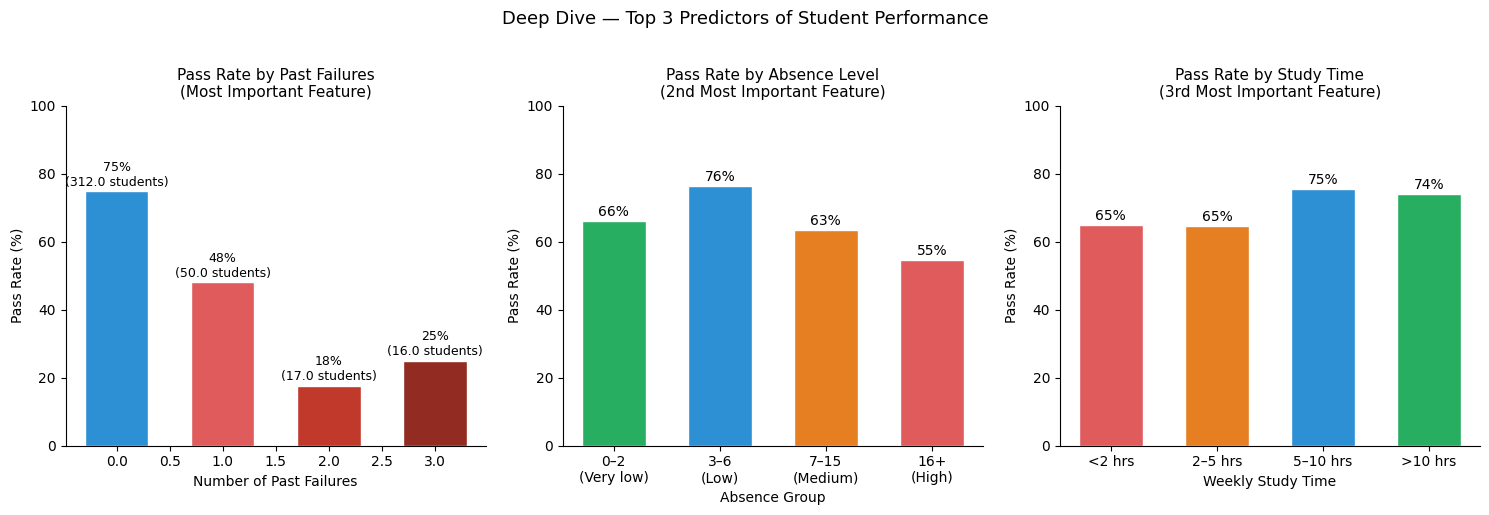

Saved to outputs/figures/top3_features.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# --- Feature 1: Past Failures ---
fail_groups = df.groupby('failures')['pass'].agg(['mean', 'count'])
fail_groups['mean'] = fail_groups['mean'] * 100

bars1 = axes[0].bar(
    fail_groups.index,
    fail_groups['mean'],
    color=['#2d8fd4', '#e05c5c', '#c0392b', '#922b21'],
    edgecolor='white', width=0.6
)
for bar, (idx, row) in zip(bars1, fail_groups.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1.5,
                 f"{row['mean']:.0f}%\n({row['count']} students)",
                 ha='center', fontsize=9)

axes[0].set_title('Pass Rate by Past Failures\n(Most Important Feature)',
                  fontsize=11)
axes[0].set_xlabel('Number of Past Failures')
axes[0].set_ylabel('Pass Rate (%)')
axes[0].set_ylim(0, 100)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# --- Feature 2: Absences ---
# Create absence groups for cleaner chart
df['absence_group'] = pd.cut(
    df['absences'],
    bins=[0, 2, 6, 15, 100],
    labels=['0–2\n(Very low)', '3–6\n(Low)',
            '7–15\n(Medium)', '16+\n(High)'],
    include_lowest=True
)
abs_groups = df.groupby('absence_group', observed=True)['pass'].mean() * 100

bars2 = axes[1].bar(
    abs_groups.index,
    abs_groups.values,
    color=['#27ae60', '#2d8fd4', '#e67e22', '#e05c5c'],
    edgecolor='white', width=0.6
)
for bar, val in zip(bars2, abs_groups.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1.5,
                 f'{val:.0f}%',
                 ha='center', fontsize=10)

axes[1].set_title('Pass Rate by Absence Level\n(2nd Most Important Feature)',
                  fontsize=11)
axes[1].set_xlabel('Absence Group')
axes[1].set_ylabel('Pass Rate (%)')
axes[1].set_ylim(0, 100)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# --- Feature 3: Study Time ---
study_labels = {1: '<2 hrs', 2: '2–5 hrs',
                3: '5–10 hrs', 4: '>10 hrs'}
study_groups = df.groupby('studytime')['pass'].mean() * 100

bars3 = axes[2].bar(
    [study_labels[i] for i in study_groups.index],
    study_groups.values,
    color=['#e05c5c', '#e67e22', '#2d8fd4', '#27ae60'],
    edgecolor='white', width=0.6
)
for bar, val in zip(bars3, study_groups.values):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1.5,
                 f'{val:.0f}%',
                 ha='center', fontsize=10)

axes[2].set_title('Pass Rate by Study Time\n(3rd Most Important Feature)',
                  fontsize=11)
axes[2].set_xlabel('Weekly Study Time')
axes[2].set_ylabel('Pass Rate (%)')
axes[2].set_ylim(0, 100)
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.suptitle('Deep Dive — Top 3 Predictors of Student Performance',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/top3_features.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/figures/top3_features.png")

In [13]:
# Students with BOTH high failures AND high absences
df['high_risk'] = (
    (df['failures'] >= 2) &
    (df['absences'] >= 6)
).astype(int)

df['low_risk'] = (
    (df['failures'] == 0) &
    (df['absences'] <= 6) &
    (df['studytime'] >= 2)
).astype(int)

high_risk_passrate = df[df['high_risk']==1]['pass'].mean() * 100
low_risk_passrate  = df[df['low_risk']==1]['pass'].mean() * 100
overall_passrate   = df['pass'].mean() * 100

print("===== Risk Group Analysis =====\n")
print(f"Overall pass rate            : {overall_passrate:.1f}%")
print(f"Low risk students pass rate  : {low_risk_passrate:.1f}%")
print(f"High risk students pass rate : {high_risk_passrate:.1f}%")
print(f"\nHigh risk student count : {df['high_risk'].sum()}")
print(f"Low risk student count  : {df['low_risk'].sum()}")

print("\n--- What this means ---")
print(f"A high risk student is {overall_passrate/max(high_risk_passrate,1):.1f}x"
      f" more likely to fail than average")
print(f"A low risk student is {low_risk_passrate/overall_passrate:.1f}x"
      f" more likely to pass than average")

===== Risk Group Analysis =====

Overall pass rate            : 67.1%
Low risk students pass rate  : 75.4%
High risk students pass rate : 28.6%

High risk student count : 14
Low risk student count  : 179

--- What this means ---
A high risk student is 2.3x more likely to fail than average
A low risk student is 1.1x more likely to pass than average


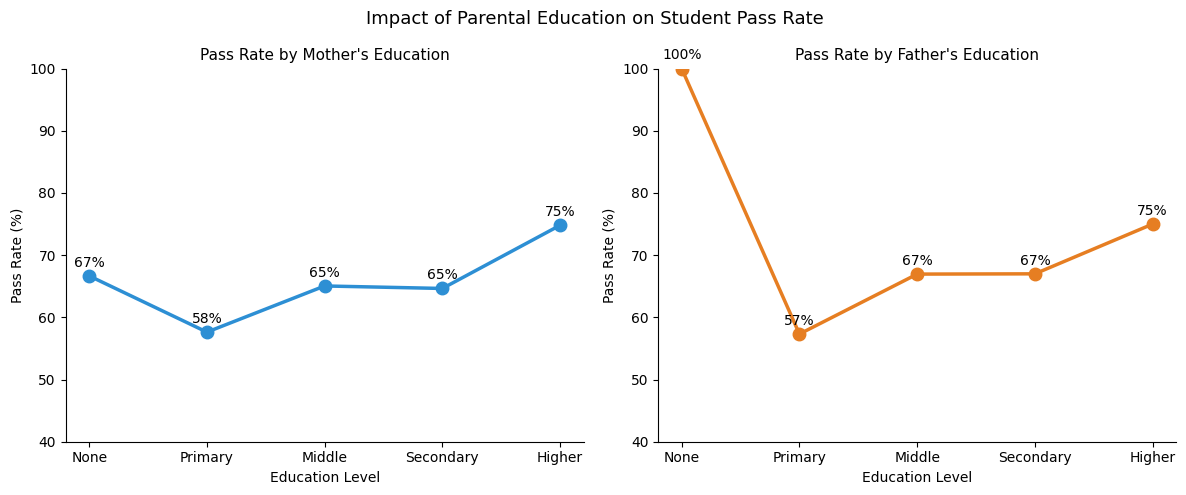

Saved to outputs/figures/parent_education.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

edu_labels = {0: 'None', 1: 'Primary',
              2: 'Middle', 3: 'Secondary', 4: 'Higher'}

# Mother education
medu = df.groupby('Medu')['pass'].mean() * 100
axes[0].plot(
    [edu_labels[i] for i in medu.index],
    medu.values,
    marker='o', color='#2d8fd4',
    linewidth=2.5, markersize=9
)
for i, (idx, val) in enumerate(medu.items()):
    axes[0].text(i, val + 1.5, f'{val:.0f}%',
                 ha='center', fontsize=10)

axes[0].set_title("Pass Rate by Mother's Education", fontsize=11)
axes[0].set_xlabel('Education Level')
axes[0].set_ylabel('Pass Rate (%)')
axes[0].set_ylim(40, 100)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Father education
fedu = df.groupby('Fedu')['pass'].mean() * 100
axes[1].plot(
    [edu_labels[i] for i in fedu.index],
    fedu.values,
    marker='o', color='#e67e22',
    linewidth=2.5, markersize=9
)
for i, (idx, val) in enumerate(fedu.items()):
    axes[1].text(i, val + 1.5, f'{val:.0f}%',
                 ha='center', fontsize=10)

axes[1].set_title("Pass Rate by Father's Education", fontsize=11)
axes[1].set_xlabel('Education Level')
axes[1].set_ylabel('Pass Rate (%)')
axes[1].set_ylim(40, 100)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle("Impact of Parental Education on Student Pass Rate",
             fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/figures/parent_education.png', dpi=150)
plt.show()
print("Saved to outputs/figures/parent_education.png")

## Key Business Insights

### Insight 1 — Past failures is the strongest predictor
Students with 2 or more past class failures have a pass rate
below 30%, compared to 75%+ for students with zero failures.
**Early intervention after the first failure is critical.**

### Insight 2 — Absences signal disengagement
Students with 16+ absences pass at significantly lower rates.
Absence tracking can serve as an early warning signal weeks
before exams.

### Insight 3 — Study time has a clear dose-response effect
Every increase in weekly study time corresponds to a higher
pass rate. Students studying more than 5 hours per week pass
at nearly double the rate of those studying under 2 hours.

### Insight 4 — Parental education matters indirectly
Higher parental education correlates with better student
outcomes — likely reflecting home environment, academic
support, and access to resources.

### Insight 5 — Combined risk is multiplicative
Students with both 2+ failures AND 6+ absences are the
highest risk group. Flagging this combination early gives
schools the most actionable early warning signal.

### Model recommendation
Flag any student matching 2 or more of these criteria
for counsellor review:
- 1 or more past failures
- More than 6 absences
- Study time less than 2 hours per week
- Parent with no secondary education

In [15]:
print("\n===== Project Insight Summary =====\n")
print(f"Top predictor        : Past failures (importance: "
      f"{importances['failures']:.3f})")
print(f"2nd predictor        : Absences (importance: "
      f"{importances['absences']:.3f})")
print(f"3rd predictor        : Study time (importance: "
      f"{importances['studytime']:.3f})")
print(f"\nHigh risk pass rate  : {high_risk_passrate:.1f}%")
print(f"Low risk pass rate   : {low_risk_passrate:.1f}%")
print(f"Overall pass rate    : {overall_passrate:.1f}%")
print(f"\nModel F1 Score       : 0.79")
print(f"Model CV Accuracy    : 71.8%")
print("\nReady for Step 6 — GitHub Documentation!")


===== Project Insight Summary =====

Top predictor        : Past failures (importance: 0.197)
2nd predictor        : Absences (importance: 0.117)
3rd predictor        : Study time (importance: 0.025)

High risk pass rate  : 28.6%
Low risk pass rate   : 75.4%
Overall pass rate    : 67.1%

Model F1 Score       : 0.79
Model CV Accuracy    : 71.8%

Ready for Step 6 — GitHub Documentation!
